In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
import numpy as np
import pickle

from rdkit import RDLogger

RDLogger.DisableLog('rdApp.*')

def calc_fps(smis, fp_func):
    fps = [fp_func(Chem.MolFromSmiles(smi)) for smi in smis]
    return fps

def fit_decomp_kde(fps_train, pipe, kde):
    
    X_train_decomp = pipe.fit_transform(fps_train)
    kde.fit(X_train_decomp)
    
    return X_train_decomp

def plot_decomp_kde(X_decomp, kde, ax):
        
    X, Y = np.meshgrid(np.linspace(-1.1, 1.1, 100), np.linspace(-1.1, 1.1, 100))
    Z = np.vstack([Y.ravel(), X.ravel()]).T
    # density at gridpoints
    Z = np.exp(kde.score_samples(Z)).reshape(100,100)

    # kernel density countour plot
    levels = np.linspace(0, Z.max(), 25)
    m = ax.contourf(X, Y, Z, levels=levels, cmap=plt.cm.Reds)
    sns.scatterplot(x=X_decomp[:, 0], y=X_decomp[:, 1], s=2, ax=ax)

    ax.grid(True)
    
    return X_decomp

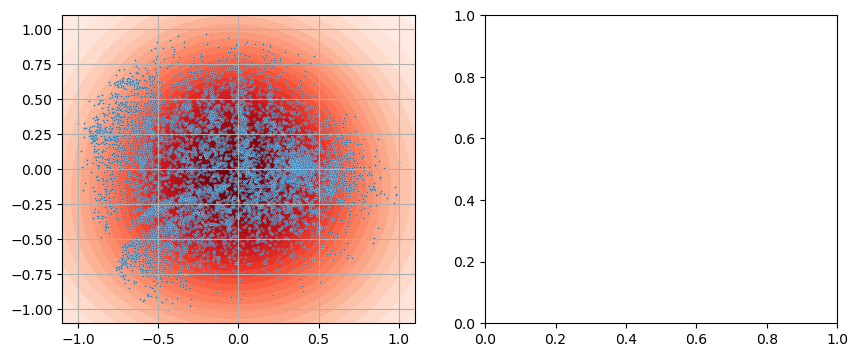

In [2]:
#fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=3).GetFingerprint
fpgen = rdFingerprintGenerator.GetAtomPairGenerator().GetFingerprint

kde = KernelDensity(kernel="gaussian", bandwidth=0.5)
#pipe = Pipeline([('decomp', PCA(n_components=2)), ('scaler', MinMaxScaler((-1,1)))])
pipe = Pipeline([('decomp', Isomap(n_components=2, n_neighbors=200)), ('scaler', MinMaxScaler((-1,1)))])

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

smis_train = [i.rstrip() for i in open("/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/data/HCs/PCCP/hydros8992.smi").readlines()]
fps_train = calc_fps(smis_train, fpgen)
X_train_decomp = fit_decomp_kde(fps_train, pipe, kde)
plot_decomp_kde(X_train_decomp, kde, ax[0])

smis_test = [i.rstrip() for i in open("/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/scratch_programs/random_mol_gen/results_01_09_25/10k_random_gen.smi").readlines()]
fps_test = calc_fps(smis_test, fpgen)
X_test_decomp = pipe.transform(fps_test)
plot_decomp_kde(X_test_decomp, kde, ax[1])
plt.show()

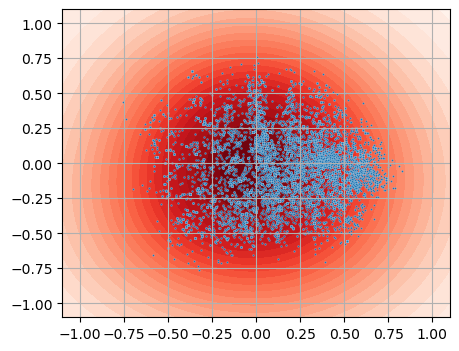

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))

smis_test = [i.rstrip() for i in open("/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/scratch_programs/random_mol_gen/res_21_09_25/valid.smi").readlines()][:10000]
fps_test = calc_fps(smis_test, fpgen)
X_test_decomp = pipe.transform(fps_test)
plot_decomp_kde(X_test_decomp, kde, ax)
plt.show()

# KDE Contour Clustering

In [4]:
from matplotlib.path import Path

def cluster_by_kde_contour(X_decomp, kde, n_groups, min_cluster_len=100, a=None):

    X, Y = np.meshgrid(
        np.linspace(-1.01, 1.01, 100), 
        np.linspace(-1.01, 1.01, 100)
    )
    Z = np.vstack([Y.ravel(), X.ravel()]).T
    # density at gridpoints
    Z = np.exp(kde.score_samples(Z)).reshape(X.shape)

    levels = np.linspace(Z.min(), Z.max(), n_groups+2)

    contours = a.contourf(X, Y, Z, levels=levels, cmap=plt.cm.Reds)
    #a.contour(X, Y, Z, levels=levels, colors="black", linewidths=0.5)

    # contour polygon containment clustering
    cluster_labels = np.full(X_decomp.shape[0], fill_value=-1)
    for cluster_id, path in enumerate(contours.get_paths()):
            poly = Path(path.vertices)
            inside = poly.contains_points(X_decomp)
            cluster_labels[inside] = cluster_id
            
    # if cluster size is smaller than minimum, combine it with the next cluster along
    smallest_cluster_len = -np.inf
    while smallest_cluster_len < min_cluster_len:
        cluster_lens = []
        for i in np.unique(cluster_labels):
            c_idxs = np.where(cluster_labels==i)[0]
            c_len = len(c_idxs)
            cluster_lens.append(c_len)
            if c_len < min_cluster_len:
                for j in c_idxs:
                    cluster_labels[j] = i+1
                    
        smallest_cluster_len = min(cluster_lens)
            
    # Alternative fast binning by quantiles (doesn't match contours exactly, but is cheap)
    #thresholds = np.quantile(density, np.linspace(0, 1, n_groups + 1))
    #cluster_labels = np.digitize(density, thresholds[1:], right=True)

    # kernel density countour plot
    a.grid(True)
    a.scatter(X_decomp[:,0], X_decomp[:,1], c=cluster_labels, cmap="viridis", s=1)
    
    return cluster_labels

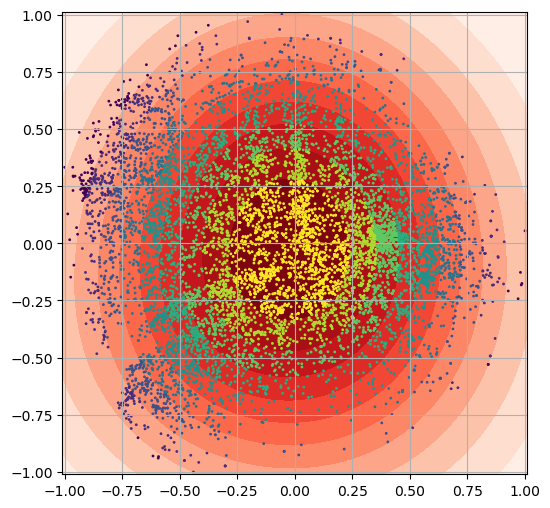

2 122
3 417
4 628
5 850
6 1197
7 1268
8 1471
9 1497
10 1542


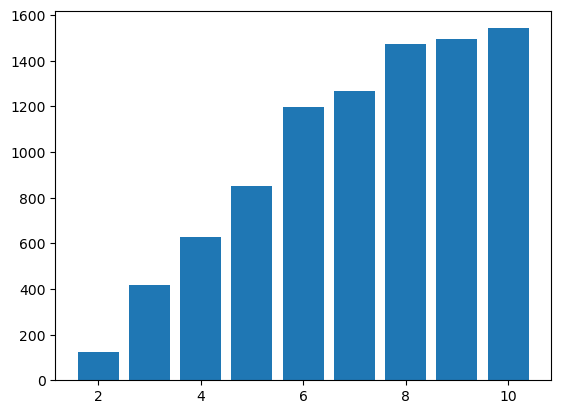

In [5]:
# training set
fig, ax = plt.subplots(figsize=(6,6))
cluster_labels = cluster_by_kde_contour(X_train_decomp, kde, 10, min_cluster_len=100, a=ax)
plt.show()

cluster_lens = []
for i in np.unique(cluster_labels):
    cl = len(np.where(cluster_labels==i)[0])
    print(i, cl)
    cluster_lens.append(cl)
    
plt.bar(np.unique(cluster_labels), cluster_lens)
plt.show()

In [6]:
# Get weights to even the emphasis of training based on the kde contour distribution
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(cluster_labels),
    y=cluster_labels
)

# dictionary to pass to class_weight argument in keras model.fit
class_weight_dict = dict(enumerate(class_weights, min(np.unique(cluster_labels))))

sample_weights = np.array([class_weight_dict[i] for i in cluster_labels])
#np.save("sample_weights_hydros8992.npy", sample_weights)

In [7]:
import pandas as pd
pd.DataFrame(sample_weights).value_counts()

0       
0.647932    1542
0.667409    1497
0.679205    1471
0.787943    1268
0.834679    1197
1.175425     850
1.590941     628
2.395950     417
8.189435     122
Name: count, dtype: int64

In [8]:
class_weight_dict

{2: 8.18943533697632,
 3: 2.3959499067412735,
 4: 1.5909412597310686,
 5: 1.1754248366013071,
 6: 0.8346792908196417,
 7: 0.7879425166491413,
 8: 0.6792053780497016,
 9: 0.6674088918577896,
 10: 0.6479319786712783}

In [83]:
# DATASET AUGMENTATION:
# enumerate SMILES strings from smaller clusters to balance
import math

new_smis_train = []
for count, smi in enumerate(smis_train):
    mol = Chem.MolFromSmiles(smi)
    
    # calculate number of smis to enumerate
    weight = class_weight_dict[cluster_labels[count]]
    smis_to_enumerate = 1
    if weight > 1.0:
        smis_to_enumerate = math.ceil(weight)
    else:
        new_smis_train.append(smi)
        continue
    
    enumerated_smis = []
    for i in range(smis_to_enumerate):
        new_smi = Chem.MolToSmiles(mol, doRandom=True)
        if new_smi not in enumerated_smis:
            enumerated_smis.append(new_smi)
            
    new_smis_train.extend(enumerated_smis)
    
len(new_smis_train)

12275

In [84]:
# with open("augmented_by_kde_clusters_hydros8992.smi", "w") as fw:
#     for smi in new_smis_train:
#         fw.write(f"{smi}\n")

# Checking cluster size on randomly generated molecules

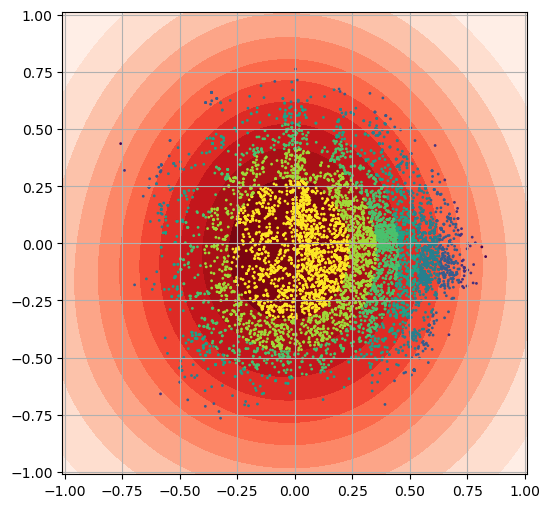

3 3
4 43
5 445
6 1003
7 1412
8 2196
9 2167
10 2731


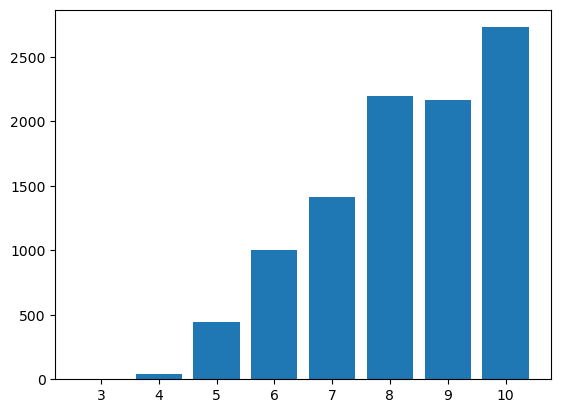

{3: 416.6666666666667, 4: 29.069767441860463, 5: 2.808988764044944, 6: 1.2462612163509472, 7: 0.8852691218130312, 8: 0.569216757741348, 9: 0.5768343331795108, 10: 0.4577077993409008}


In [10]:
# test set
fig, ax = plt.subplots(figsize=(6,6))
cluster_labels = cluster_by_kde_contour(X_test_decomp, kde, 10, min_cluster_len=1, a=ax)
plt.show()

cluster_lens = []
for i in np.unique(cluster_labels):
    cl = len(np.where(cluster_labels==i)[0])
    print(i, cl)
    cluster_lens.append(cl)
    
plt.bar(np.unique(cluster_labels), cluster_lens)
plt.show()

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(cluster_labels),
    y=cluster_labels
)

# dictionary to pass to class_weight argument in keras model.fit
class_weight_dict = dict(enumerate(class_weights, min(np.unique(cluster_labels))))
print(class_weight_dict)
sample_weights = np.array([class_weight_dict[i] for i in cluster_labels])

# Larger Dataset

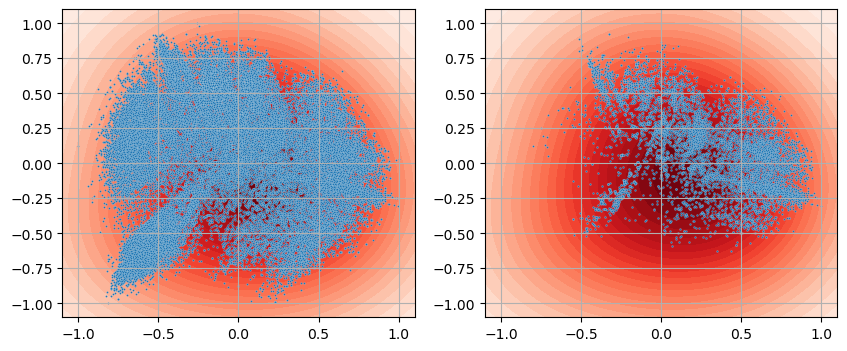

In [17]:
kde = KernelDensity(kernel="gaussian", bandwidth=0.5)
pipe = Pipeline([('decomp', PCA(n_components=2)), ('scaler', MinMaxScaler((-1,1)))])

fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=3).GetFingerprint

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

smis_train = [i.rstrip() for i in open("/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/data/HCs/combined_set.smi").readlines()]
fps_train = calc_fps(smis_train, fpgen)
X_train_decomp = fit_decomp_kde(fps_train, pipe, kde)
plot_decomp_kde(X_train_decomp, kde, ax[0])

smis_test = [i.rstrip() for i in open("/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/data/HCs/PCCP/hydros8992.smi").readlines()]
fps_test = calc_fps(smis_test, fpgen)
X_test_decomp = pipe.transform(fps_test)
plot_decomp_kde(X_test_decomp, kde, ax[1])
plt.show()

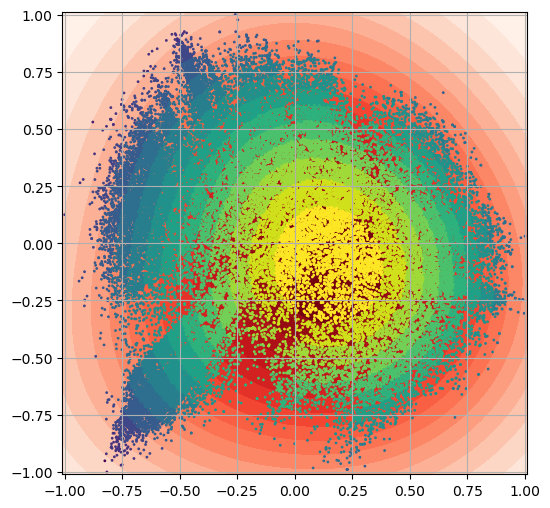

1 1
2 2
3 96
4 640
5 2145
6 4276
7 5438
8 5491
9 5484
10 5587
11 5351
12 4941
13 4774
14 4380
15 3585


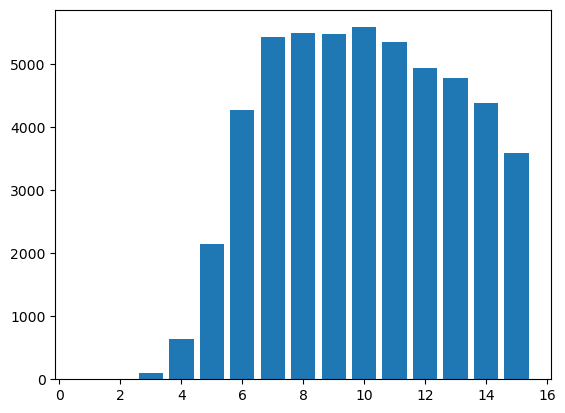

In [18]:
fig, ax = plt.subplots(figsize=(6,6))
cluster_labels = cluster_by_kde_contour(X_train_decomp, kde, 15, ax)
plt.show()

cluster_lens = []
for i in np.unique(cluster_labels):
    cl = len(np.where(cluster_labels==i)[0])
    print(i, cl)
    cluster_lens.append(cl)
    
plt.bar(np.unique(cluster_labels), cluster_lens)
plt.show()